<a href="https://colab.research.google.com/github/nomad-gokul/AI-Based-Reliable-Droplet-Routing-for-MEDA-Biochips-Using-Deep-Reinforcement-Learning/blob/main/run_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MEDA droplet routing — run all experiments

**Before you start:** Runtime → Change runtime type → **T4 GPU** (needed only for Experiment 4).

Run the cells from top to bottom. Results (figures + CSV files) are saved in `meda-routing/results/`.

## 1. Upload and unzip the project
Run this cell, then click **Choose Files** and pick `meda-routing.zip`.

In [1]:
from google.colab import files
up = files.upload()
!unzip -oq meda-routing.zip
%cd meda-routing
!ls

Saving meda-routing.zip to meda-routing.zip
/content/meda-routing
experiments  README.md	       run_experiments.ipynb
medaroute    requirements.txt  tests


## 2. Install libraries (about 1 minute)
Colab already has PyTorch; this adds Gymnasium and Stable-Baselines3.

In [2]:
!pip install -q gymnasium stable-baselines3
import torch; print("GPU available:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.0 MB/s eta 0:00:00
GPU available: True


## 3. Experiment 1 — one task, both routers' paths

saved results/exp1_paths.png


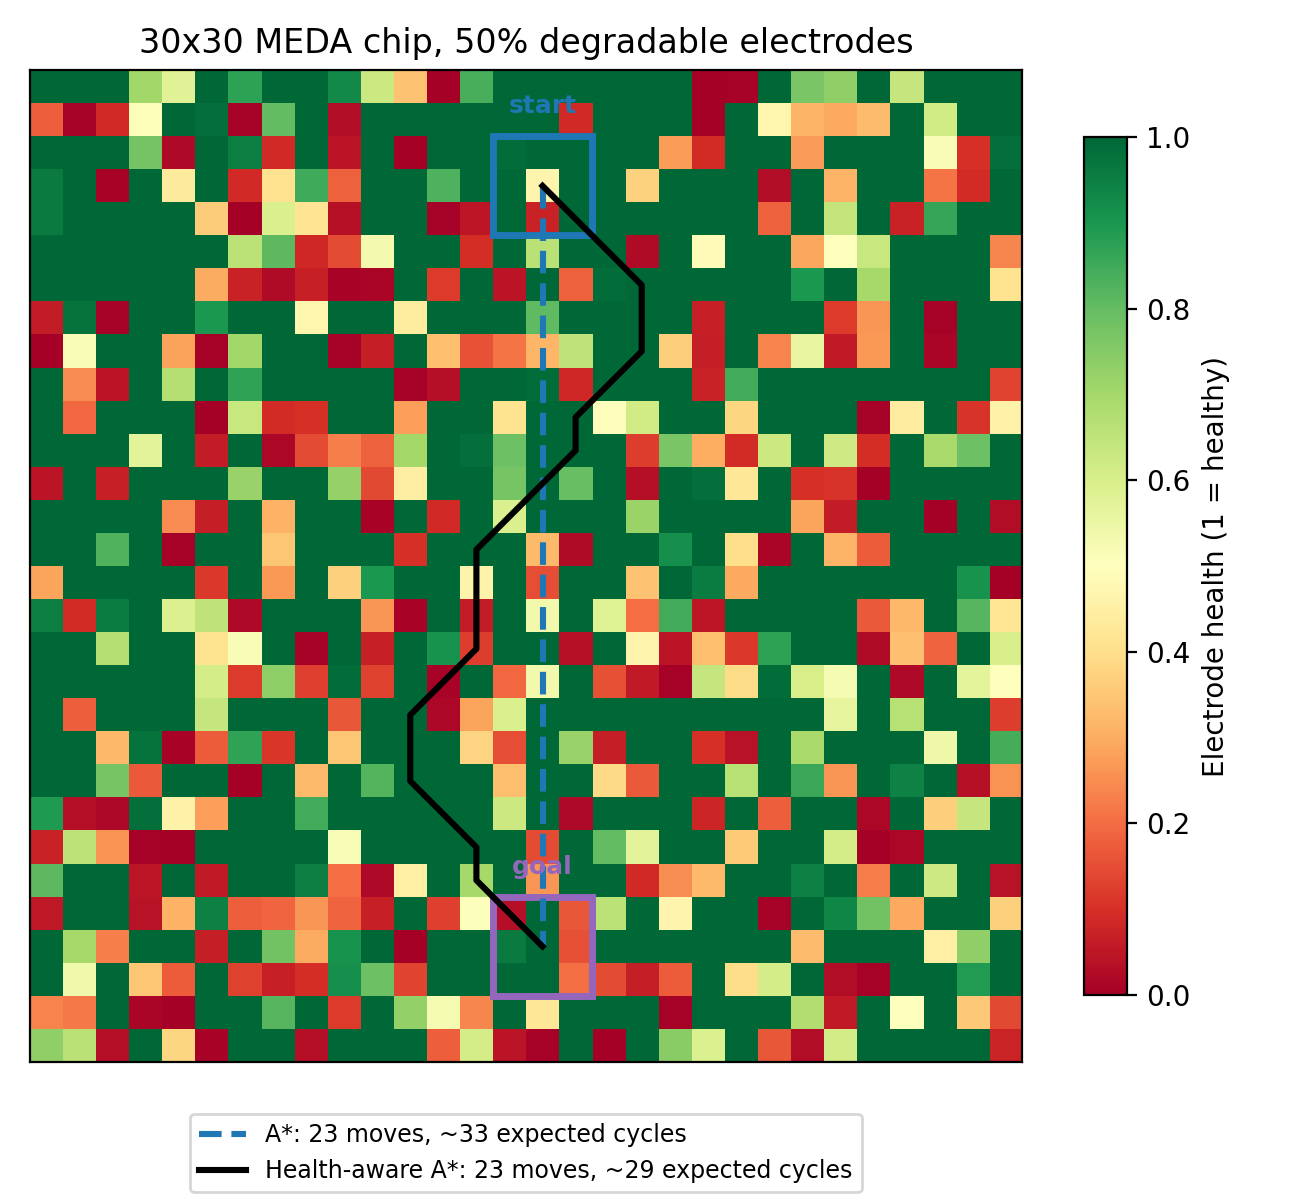

In [3]:
!python experiments/exp1_visualize.py
from IPython.display import Image, display
display(Image("results/exp1_paths.png", width=520))

## 4. Experiment 2 — success rate vs degradation level (~15 s)

  0%  A*               success=1.000  steps(success)=14.6  path=14.6
  0%  Health-aware A*  success=1.000  steps(success)=14.6  path=14.6
 10%  A*               success=0.994  steps(success)=15.4  path=14.4
 10%  Health-aware A*  success=1.000  steps(success)=14.8  path=14.4
 30%  A*               success=0.918  steps(success)=17.5  path=14.2
 30%  Health-aware A*  success=0.970  steps(success)=16.3  path=14.2
 50%  A*               success=0.634  steps(success)=19.2  path=14.3
 50%  Health-aware A*  success=0.848  steps(success)=18.6  path=14.4
 70%  A*               success=0.228  steps(success)=18.2  path=14.2
 70%  Health-aware A*  success=0.492  steps(success)=19.8  path=14.3
saved to results


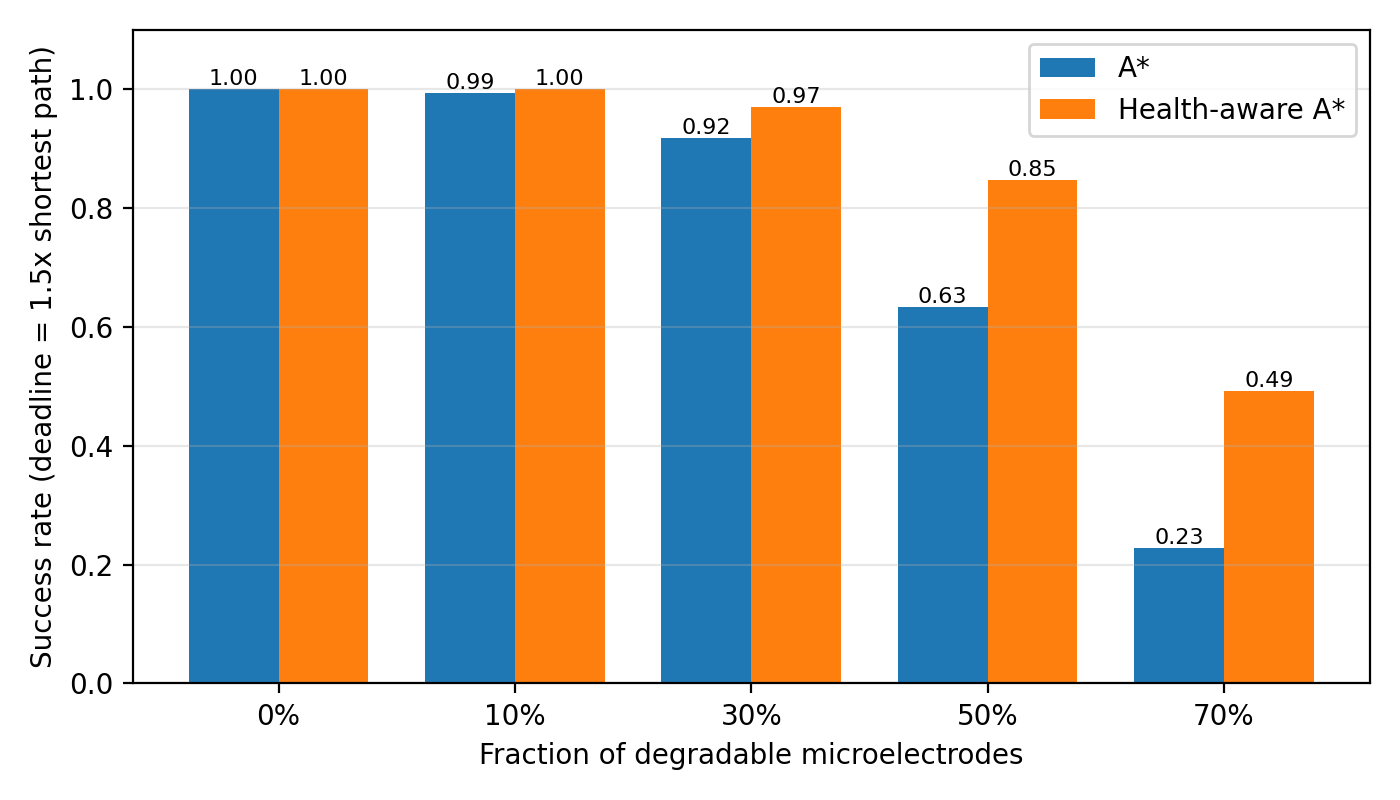

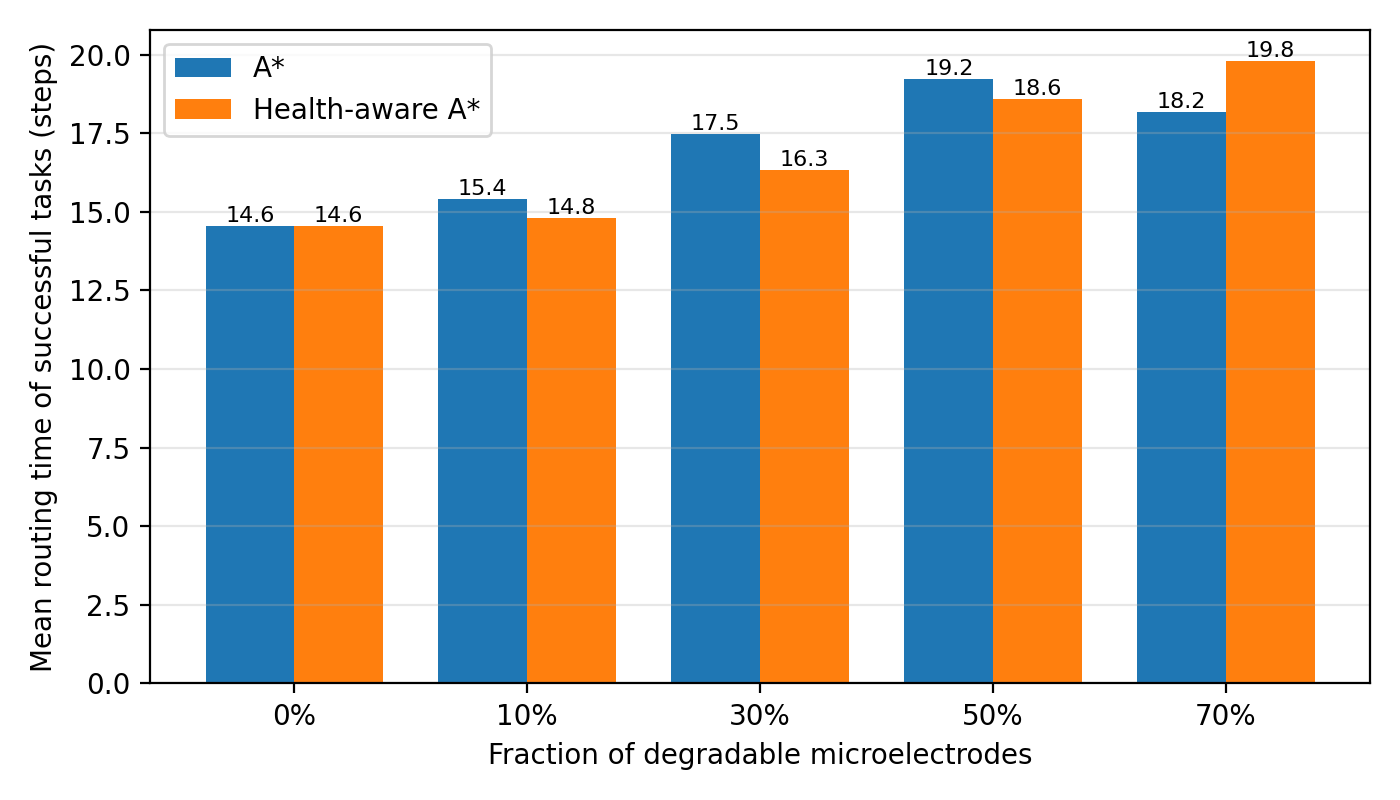

In [4]:
!python experiments/exp2_degradation_levels.py
display(Image("results/exp2_success.png", width=600))
display(Image("results/exp2_steps.png", width=600))

## 5. Experiment 3 — chip lifetime (~1–2 min)

In [ ]:
!python experiments/exp3_lifetime.py
display(Image("results/exp3_lifetime.png", width=600))
display(Image("results/exp3_health.png", width=700))

chip 0  A*               first failure at task  223  overall success 0.521
chip 0  Health-aware A*  first failure at task  393  overall success 0.768
chip 1  A*               first failure at task  303  overall success 0.537
chip 1  Health-aware A*  first failure at task  378  overall success 0.726
chip 2  A*               first failure at task  255  overall success 0.443
chip 2  Health-aware A*  first failure at task  285  overall success 0.719
chip 3  A*               first failure at task  228  overall success 0.550
chip 3  Health-aware A*  first failure at task  679  overall success 0.793
chip 4  A*               first failure at task  205  overall success 0.465
chip 4  Health-aware A*  first failure at task  336  overall success 0.721
chip 5  A*               first failure at task  302  overall success 0.471
chip 5  Health-aware A*  first failure at task  304  overall success 0.698
chip 6  A*               first failure at task  207  overall success 0.481


## 6. Experiment 4 — PPO agent, with vs without the health map

First a **quick test** (about 2 min) to check everything works — the agent will not have learned much yet.

In [ ]:
!python experiments/exp4_ppo.py --timesteps 20000 --eval_episodes 100 --out results/smoke

**Full run.** Trains both agents. Start with 500k steps each; if the learning curve is still rising at the end, rerun with `--timesteps 1500000`.

Keep the browser tab open — Colab stops idle sessions. Models are saved, so you can re-evaluate later with `--eval_only`.

In [ ]:
!python experiments/exp4_ppo.py --timesteps 500000
display(Image("results/exp4_learning_curve.png", width=600))
display(Image("results/exp4_eval.png", width=600))

## 7. Download all results

In [ ]:
!zip -qr results.zip results
files.download("results.zip")